In [1]:
import geopandas as gpd
import pandas as pd
from shapely import wkt

In [2]:
df = gpd.read_file('/Users/brendanjarrell/Desktop/hitl_reviewDS.csv')

df["st_astext"] = df["st_astext"].apply(wkt.loads)
hitl_gdf = gpd.GeoDataFrame(
    df,
    geometry="st_astext",
    crs="EPSG:4326"  # adjust if coordinates are not lon/lat
).drop_duplicates(subset=['id'], keep='first')

hitl_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# Count number of geometries.

In [86]:
sample_multipolygon = hitl_gdf['st_astext'].iloc[0]
num_geometries = len(sample_multipolygon.geoms)
print(f"Number of geometries in the first MultiPolygon: {num_geometries}")

hitl_gdf['geometry_count'] = hitl_gdf['st_astext'].apply(lambda geom: len(geom.geoms))
print("\nFirst 5 rows with geometry counts:")
print(hitl_gdf[['st_astext']].head())

Number of geometries in the first MultiPolygon: 22

First 5 rows with geometry counts:
                                           st_astext
0  MULTIPOLYGON (((25.59746 74.29779, 25.59814 74...
1  MULTIPOLYGON (((26.11107 73.59329, 26.11176 73...
2  MULTIPOLYGON (((-14.3557 48.05351, -14.35501 4...
3  MULTIPOLYGON (((-91.66586 0.58359, -91.66105 0...
4  MULTIPOLYGON (((-91.35618 0.23134, -91.35412 0...


# Size of the largest and median most polygon in a multipolygon.

In [87]:
hitl_gdf_newProj = hitl_gdf.to_crs('EPSG:6933')

In [88]:
hitl_gdf_newProj.iloc[0]['st_astext'].area

10430189.37089026

In [89]:
hitl_gdf_newProj['largest_area'] = hitl_gdf_newProj['st_astext'].apply(lambda geom: max(part.area for part in geom.geoms))


In [7]:
test = hitl_gdf_newProj['st_astext'].iloc[0]

max([part.area for part in test.geoms])

3896792.4023594037

# Median pixel area of a multipolygon.

In [90]:
test = hitl_gdf_newProj['st_astext'].iloc[0]
num_geom = len(test.geoms)
middle = num_geom // 2
areas = [part.area for part in test.geoms]
median = sorted(areas)[middle]

# Apply to all members of the dataframe
def median_area(multipoly):
    num_geom = len(multipoly.geoms)
    middle = num_geom // 2
    areas = [part.area for part in multipoly.geoms]
    return sorted(areas)[middle]

hitl_gdf_newProj['median_area'] = hitl_gdf_newProj['st_astext'].apply(median_area)


In [92]:
hitl_gdf_newProj.columns

Index(['id', 'slick_timestamp', 'st_astext', 'machine_cls', 'hitl_cls',
       'machine_confidence', 'length', 'area', 'perimeter', 'centroid',
       'polsby_popper', 'fill_factor', 'centerlines', 'aspect_ratio_factor',
       'max_source_collated_score', 'geometry_count', 'largest_area',
       'median_area'],
      dtype='object')

In [93]:
hitl_gdf_newProj = hitl_gdf_newProj[hitl_gdf_newProj['hitl_cls'].isin(['1','6','7','8'])]
hitl_gdf_newProj["is_slick"] = hitl_gdf_newProj['hitl_cls'].isin(['6','7','8'])

In [94]:
hitl_gdf_newProj

,id,slick_timestamp,st_astext,machine_cls,hitl_cls,machine_confidence,length,area,perimeter,centroid,polsby_popper,fill_factor,centerlines,aspect_ratio_factor,max_source_collated_score,geometry_count,largest_area,median_area,is_slick
0,3273057,2024-07-21 15:44:47,"MULTIPOLYGON (((2469803.506 7065900.626, 24698...",5,1,0.9600062966346741,90479.42156099,10430194.534472644,179240.77044128766,0101000020E61000001933401D625139403062AE07B3AA...,0.004079704134171181,0.17341434501669312,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.9998600689270918,-2.997074592798687,22,3.896792e+06,3129.929236,False
1,3278751,2024-07-21 15:44:35,"MULTIPOLYGON (((2519359.921 7040735.513, 25194...",5,1,0.945455014705658,187059.15992051,17981273.724743545,347689.96294476854,0101000020E6100000347A485AE2923940F5E74B91A395...,0.001869157978317394,0.08627849616058189,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.9999936640027093,-3.0911078359252775,55,3.868119e+06,1653.120907,False
2,3264093,2024-07-20 07:05:18,"MULTIPOLYGON (((-1385127.9 5449983.516, -13850...",5,1,0.9159122705459595,76377.44526714,22870602.19789487,213312.21003821932,0101000020E6100000AE579E00649A2DC0A7624577230D...,0.006316202329465258,0.45344901672487353,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.9999960041891336,-4.458064854763842,11,1.324534e+07,46877.610144,False
3,3030492,2024-08-10 11:50:22,"MULTIPOLYGON (((-8844497.568 74449.753, -88440...",5,1,0.9863162040710449,20201.06759414,34918265.7979765,151266.87753361906,0101000020E610000048A41BD082ED56C0F75646F00C07...,0.01917674291267693,0.19226207056489528,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.40790214755351906,-1.0409978140947282,35,3.362978e+07,5809.306902,False
4,3022415,2024-08-21 00:27:07,"MULTIPOLYGON (((-8814617.986 29513.364, -88144...",5,1,0.9152988195419312,11577.03241622,16737114.913490694,84535.91637279905,0101000020E610000032DFBEFF6BD756C028093ABC1562...,0.02943119745078223,0.36656557433898673,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.3093327878017077,NULL,10,7.254290e+06,23220.761310,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7964,3711339,2023-01-20 00:09:18,"MULTIPOLYGON (((-8778969.2 3177176.287, -87789...",5,1,0.7757794857025146,8567.4194362,1813115.1084502637,21918.181074898355,0101000020E6100000059DD87A12C156C01284BFD39AC1...,0.04742706177694859,0.14197932079736814,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.5290733032504711,0.016548703178519825,6,1.498754e+06,110033.660177,False
7965,3695903,2023-03-09 00:09:42,"MULTIPOLYGON (((-8812892.811 3239682.891, -881...",5,1,0.722631573677063,16576.65736051,996556.0341318846,24299.168876423963,0101000020E61000005C7B6303C2D856C022CC5F29F83E...,0.021209417859542463,0.015228287762947532,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.8554685236112738,0.4181408682614034,20,3.234532e+05,26091.303122,False
7968,3277245,2024-07-01 16:39:56,"MULTIPOLYGON (((2005179.13 4409261.432, 200531...",5,7,0.9154301881790161,13828.70381106,2345405.0369896293,37708.364498245755,0101000020E6100000322E77D19DBE3440D7021C2DC687...,0.020727757767558776,0.1217709868791142,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.9512273807685936,0.49674621702666033,5,1.935697e+06,130362.534382,True
7969,3506646,2024-09-23 16:39:56,"MULTIPOLYGON (((1860479.717 4310910.021, 18610...",5,8,0.9917237162590027,5489.98343405,3303893.486179292,16628.510751621943,0101000020E6100000607FB83EDC4F334014A335DC2909...,0.15015133247697116,0.5593938214986587,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.3746504445126545,0.13660933993296148,3,3.294313e+06,4717.854758,True


In [95]:
# Exporting modified dataframe to CSV.
hitl_gdf_newProj_red = hitl_gdf_newProj.drop(columns=['hitl_cls','centroid','centerlines', 'st_astext', 'slick_timestamp'], axis=1)
hitl_gdf_newProj_red.to_csv('/Users/brendanjarrell/Desktop/hitl_featsAdded_011426.csv', index=False)

# Modify the unattributed detections ds.

In [96]:
df = pd.read_csv("/Users/brendanjarrell/Desktop/unattributed_noCollation_sampleData.csv")


filtered_unatt = (df[['id', 'slick_timestamp', 'geometry', 'hitl_cls',
       'length', 'area', 'perimeter','polsby_popper', 'fill_factor', 'centerlines', 'aspect_ratio_factor', 'machine_confidence',
       'max_source_collated_score']])
filtered_unatt['machine_cls'] = df['cls']
filtered_unatt['hitl_cls'] = None

gdf = gpd.GeoDataFrame(
    filtered_unatt,
    geometry=gpd.GeoSeries.from_wkt(filtered_unatt["geometry"]),
    crs="EPSG:4326"
).drop_duplicates(subset=['id'], keep='first')

filt_newProj = gdf.to_crs('EPSG:6933')

filt_newProj['geometry_count'] = filt_newProj['geometry'].apply(lambda geom: len(geom.geoms))
filt_newProj['largest_area'] = filt_newProj['geometry'].apply(lambda geom: max(part.area for part in geom.geoms))

def median_area(multipoly):
    num_geom = len(multipoly.geoms)
    middle = num_geom // 2
    areas = [part.area for part in multipoly.geoms]
    return sorted(areas)[middle]

filt_newProj['median_area'] = filt_newProj['geometry'].apply(median_area)

/var/folders/9v/x_rm5y652vnf054kd69_9s100000gn/T/ipykernel_71621/3400994830.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_unatt['machine_cls'] = df['cls']
/var/folders/9v/x_rm5y652vnf054kd69_9s100000gn/T/ipykernel_71621/3400994830.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_unatt['hitl_cls'] = None


In [100]:
filt_arfSorted = filt_newProj.sort_values(by='max_source_collated_score', ascending=False).iloc[:100]

filt_arfSorted

,id,slick_timestamp,geometry,hitl_cls,length,area,perimeter,polsby_popper,fill_factor,centerlines,aspect_ratio_factor,machine_confidence,max_source_collated_score,machine_cls,geometry_count,largest_area,median_area
0,3795942,2025-01-03T16:13:47,"MULTIPOLYGON (((-14385136.242 6305804.848, -14...",None,2113.405623,2.170036e+06,13746.061935,0.144318,0.706595,"{'type': 'FeatureCollection', 'features': [{'i...",0.106278,0.927770,NaN,5,1,2.170036e+06,2.170036e+06
1,3795446,2025-01-03T04:48:21,"MULTIPOLYGON (((1970060.344 4565213.687, 19701...",None,9653.203809,6.010783e+06,47608.556002,0.033325,0.096572,"{'type': 'FeatureCollection', 'features': [{'i...",0.312495,0.912630,NaN,5,22,3.287560e+06,9.120613e+03
2,3804988,2025-01-13T07:59:40,"MULTIPOLYGON (((14202474.495 6303134.675, 1420...",None,24360.189255,1.793790e+07,150569.266075,0.009943,0.071232,"{'type': 'FeatureCollection', 'features': [{'i...",0.418001,0.855584,NaN,5,72,5.184669e+06,8.992430e+03
3,3804923,2025-01-12T20:45:21,"MULTIPOLYGON (((13733350.288 6262624.652, 1373...",None,46740.923974,4.251849e+07,392034.868595,0.003476,0.049522,"{'type': 'FeatureCollection', 'features': [{'i...",0.403028,0.908770,NaN,4,178,1.293406e+07,6.108638e+03
4,3794121,2025-01-01T18:31:09,"MULTIPOLYGON (((15843997.125 -2520880.949, 158...",None,7782.072774,1.211335e+06,10302.856573,0.143403,0.179357,"{'type': 'FeatureCollection', 'features': [{'i...",0.234287,0.819468,NaN,5,2,1.020356e+06,1.020356e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3799025,2025-01-07T15:28:13,"MULTIPOLYGON (((2500674.195 7048772.568, 25008...",None,5630.077302,4.338286e+05,15795.053724,0.021852,0.079829,"{'type': 'FeatureCollection', 'features': [{'i...",0.654697,0.654316,NaN,5,22,2.013717e+05,3.271831e+03
96,3806322,2025-01-14T18:34:44,"MULTIPOLYGON (((-1300725.658 6675016.078, -130...",None,8804.488370,1.781432e+06,30067.109825,0.024763,0.034371,"{'type': 'FeatureCollection', 'features': [{'i...",0.320895,0.661167,NaN,5,24,5.539084e+05,9.742206e+03
97,3804177,2025-01-12T17:27:41,"MULTIPOLYGON (((-16140948.607 6380359.05, -161...",None,2518.208403,3.931306e+05,7146.345612,0.096734,0.216976,"{'type': 'FeatureCollection', 'features': [{'i...",0.282678,0.774166,NaN,3,4,2.688117e+05,6.361555e+04
98,3801021,2025-01-09T15:11:22,"MULTIPOLYGON (((3183794.647 7020936.987, 31841...",None,12057.020643,3.981660e+05,15034.517749,0.022136,0.030163,"{'type': 'FeatureCollection', 'features': [{'i...",0.130188,0.635981,NaN,5,23,1.167613e+05,3.436967e+03


In [50]:
id_ls = list(filt_arfSorted['id'])

url_ls = []
i=1
for item in id_ls:
    url_ls += [i, f"https://cerulean.skytruth.org/?slick_id={item}"]
    i+=1

In [51]:
url_ls

[1,
 'https://cerulean.skytruth.org/?slick_id=3794741',
 2,
 'https://cerulean.skytruth.org/?slick_id=3802538',
 3,
 'https://cerulean.skytruth.org/?slick_id=3797586',
 4,
 'https://cerulean.skytruth.org/?slick_id=3804546',
 5,
 'https://cerulean.skytruth.org/?slick_id=3805521',
 6,
 'https://cerulean.skytruth.org/?slick_id=3805612',
 7,
 'https://cerulean.skytruth.org/?slick_id=3801618',
 8,
 'https://cerulean.skytruth.org/?slick_id=3796808',
 9,
 'https://cerulean.skytruth.org/?slick_id=3796095',
 10,
 'https://cerulean.skytruth.org/?slick_id=3805100',
 11,
 'https://cerulean.skytruth.org/?slick_id=3804597',
 12,
 'https://cerulean.skytruth.org/?slick_id=3794223',
 13,
 'https://cerulean.skytruth.org/?slick_id=3805233',
 14,
 'https://cerulean.skytruth.org/?slick_id=3802300',
 15,
 'https://cerulean.skytruth.org/?slick_id=3805479',
 16,
 'https://cerulean.skytruth.org/?slick_id=3802540',
 17,
 'https://cerulean.skytruth.org/?slick_id=3800126',
 18,
 'https://cerulean.skytruth.org/?sl

In [102]:
# Load in data
hitl_gdf_newProj_red = gpd.read_file('/Users/brendanjarrell/Desktop/hitl_featsAdded_011426.csv')

In [103]:
# filter positive HITL classes and sample 2400 rows
pos = hitl_gdf_newProj_red[hitl_gdf_newProj_red['is_slick'] == 'True']

hitl_pos_sample = pos.copy()

# filter negative HITL classes and sample 1200 rows
neg = hitl_gdf_newProj_red[hitl_gdf_newProj_red['is_slick'] == 'False']
hitl_neg_sample = neg.copy()

# combine positive and negative samples, along with the filtered unattributed data
combined_ds = pd.concat([hitl_pos_sample, hitl_neg_sample, filt_newProj]).drop(columns = ['slick_timestamp','geometry','hitl_cls','centerlines']).fillna({'is_slick':'False'})

In [104]:
# how many positives
len(combined_ds[combined_ds['is_slick'] == 'True'])

2365

In [105]:
combined_ds.reset_index(drop=True).to_csv('/Users/brendanjarrell/Desktop/cerulean_detections_all.csv', index=False)

# Looking into wake signatures in negative HITL dataset.

In [ ]:
# Grab high max_source_collated_score, aspect_ratio_factor from negative HITL dataset.

# convert potential string/object columns to numeric (coerce invalid values to NaN)
neg['max_source_collated_score'] = pd.to_numeric(neg['max_source_collated_score'], errors='coerce')
neg['aspect_ratio_factor'] = pd.to_numeric(neg['aspect_ratio_factor'], errors='coerce')

potential_wakes = (neg['max_source_collated_score'] >= 0.5) & (neg['aspect_ratio_factor'] >= 0.9)

/var/folders/9v/x_rm5y652vnf054kd69_9s100000gn/T/ipykernel_71621/3555987161.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neg['max_source_collated_score'] = pd.to_numeric(neg['max_source_collated_score'], errors='coerce')
/var/folders/9v/x_rm5y652vnf054kd69_9s100000gn/T/ipykernel_71621/3555987161.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neg['aspect_ratio_factor'] = pd.to_numeric(neg['aspect_ratio_factor'], errors='coerce')


<Axes: >

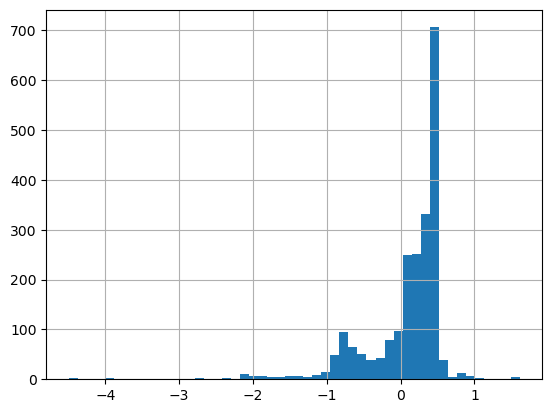

In [66]:
pos[pos['max_source_collated_score'] != 'NULL']['max_source_collated_score'].astype(float).hist(bins=50)

In [77]:
len(neg[(neg['max_source_collated_score'] >= -3) & (neg['aspect_ratio_factor'] >= 0)])

3027

In [51]:
# id_ls = list(neg[neg['aspect_ratio_factor'] >= 0.9]['id'])

id_ls = neg[(neg['max_source_collated_score'] >= 0.0) & (neg['aspect_ratio_factor'] >= 0.9)]['id']

url_ls = []
i=1
for item in id_ls:
    url_ls += [i, f"https://cerulean.skytruth.org/?slick_id={item}",neg[(neg['id'] == item)]['max_source_collated_score'].values[0], neg[(neg['id'] == item)]['aspect_ratio_factor'].values[0]]
    i+=1

url_ls

[1,
 'https://cerulean.skytruth.org/?slick_id=3581401',
 np.float64(0.1931748725387755),
 np.float64(0.9940731578990588),
 2,
 'https://cerulean.skytruth.org/?slick_id=3091272',
 np.float64(0.5118213271936153),
 np.float64(0.9307620920156854),
 3,
 'https://cerulean.skytruth.org/?slick_id=3922589',
 np.float64(0.881619852614275),
 np.float64(0.90609039332082),
 4,
 'https://cerulean.skytruth.org/?slick_id=3844941',
 np.float64(0.0276741801847903),
 np.float64(0.953067588630738),
 5,
 'https://cerulean.skytruth.org/?slick_id=3020337',
 np.float64(1.1988376910608216),
 np.float64(0.9998889089412716),
 6,
 'https://cerulean.skytruth.org/?slick_id=3051790',
 np.float64(0.0345766738477231),
 np.float64(0.9999798490883698),
 7,
 'https://cerulean.skytruth.org/?slick_id=3341817',
 np.float64(1.59559433430994),
 np.float64(0.9923154895457048),
 8,
 'https://cerulean.skytruth.org/?slick_id=3348786',
 np.float64(0.9921397369244908),
 np.float64(0.9998917646933868),
 9,
 'https://cerulean.skytrut

In [20]:
neg['max_source_collated_score'].describe()

count    3097.000000
mean       -0.445582
std         0.911711
min        -4.493270
25%        -0.857363
50%        -0.367487
75%         0.175130
max         2.706248
Name: max_source_collated_score, dtype: float64

In [19]:
potential_wakes

potential_wakes[potential_wakes == 'True']

Series([], dtype: bool)

# Doing Ethan's thing

In [36]:
hitl_gdf = gpd.read_file('/Users/brendanjarrell/Desktop/hitl_reviewDS.csv')
hitl_gdf = hitl_gdf[hitl_gdf['hitl_cls'].isin(['1','6','7','8'])]
hitl_gdf["is_slick"] = hitl_gdf['hitl_cls'].isin(['6','7','8'])


In [38]:
hitl_gdf.head()

,id,slick_timestamp,st_astext,machine_cls,hitl_cls,machine_confidence,length,area,perimeter,centroid,polsby_popper,fill_factor,centerlines,aspect_ratio_factor,max_source_collated_score,is_slick
0,3273057,2024-07-21 15:44:47,"MULTIPOLYGON(((25.597458 74.297791,25.598145 7...",5,1,0.9600062966346741,90479.42156099,10430194.534472644,179240.77044128766,0101000020E61000001933401D625139403062AE07B3AA...,0.004079704134171181,0.17341434501669312,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.9998600689270918,-2.997074592798687,False
1,3278751,2024-07-21 15:44:35,"MULTIPOLYGON(((26.111069 73.593292,26.111755 7...",5,1,0.945455014705658,187059.15992051,17981273.724743545,347689.96294476854,0101000020E6100000347A485AE2923940F5E74B91A395...,0.001869157978317394,0.08627849616058189,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.9999936640027093,-3.0911078359252775,False
2,3264093,2024-07-20 07:05:18,"MULTIPOLYGON(((-14.355698 48.053513,-14.355011...",5,1,0.9159122705459595,76377.44526714,22870602.19789487,213312.21003821932,0101000020E6100000AE579E00649A2DC0A7624577230D...,0.006316202329465258,0.45344901672487353,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.9999960041891336,-4.458064854763842,False
3,3030492,2024-08-10 11:50:22,"MULTIPOLYGON(((-91.665857 0.583594,-91.66105 0...",5,1,0.9863162040710449,20201.06759414,34918265.7979765,151266.87753361906,0101000020E610000048A41BD082ED56C0F75646F00C07...,0.01917674291267693,0.19226207056489528,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.40790214755351906,-1.0409978140947282,False
4,3022415,2024-08-21 00:27:07,"MULTIPOLYGON(((-91.35618 0.231345,-91.35412 0....",5,1,0.9152988195419312,11577.03241622,16737114.913490694,84535.91637279905,0101000020E610000032DFBEFF6BD756C028093ABC1562...,0.02943119745078223,0.36656557433898673,"{""type"": ""FeatureCollection"", ""features"": [{""i...",0.3093327878017077,NULL,False


In [ ]:
hitl_gdf.columns

#make hitl class a new column



Index(['id', 'slick_timestamp', 'st_astext', 'machine_cls', 'hitl_cls',
       'machine_confidence', 'length', 'area', 'perimeter', 'centroid',
       'polsby_popper', 'fill_factor', 'centerlines', 'aspect_ratio_factor',
       'max_source_collated_score'],
      dtype='object')

In [ ]:

hitl_gdf_reduced = (hitl_gdf.drop(columns=['hitl_cls','machine_cls','centroid','centerlines', 'st_astext', 'max_source_collated_score', 'slick_timestamp', 'machine_confidence'], axis=1))

In [40]:
hitl_gdf_reduced

,id,length,area,perimeter,polsby_popper,fill_factor,aspect_ratio_factor,is_slick
0,3273057,90479.42156099,10430194.534472644,179240.77044128766,0.004079704134171181,0.17341434501669312,0.9998600689270918,False
1,3278751,187059.15992051,17981273.724743545,347689.96294476854,0.001869157978317394,0.08627849616058189,0.9999936640027093,False
2,3264093,76377.44526714,22870602.19789487,213312.21003821932,0.006316202329465258,0.45344901672487353,0.9999960041891336,False
3,3030492,20201.06759414,34918265.7979765,151266.87753361906,0.01917674291267693,0.19226207056489528,0.40790214755351906,False
4,3022415,11577.03241622,16737114.913490694,84535.91637279905,0.02943119745078223,0.36656557433898673,0.3093327878017077,False
...,...,...,...,...,...,...,...,...
7964,3711339,8567.4194362,1813115.1084502637,21918.181074898355,0.04742706177694859,0.14197932079736814,0.5290733032504711,False
7965,3695903,16576.65736051,996556.0341318846,24299.168876423963,0.021209417859542463,0.015228287762947532,0.8554685236112738,False
7968,3277245,13828.70381106,2345405.0369896293,37708.364498245755,0.020727757767558776,0.1217709868791142,0.9512273807685936,True
7969,3506646,5489.98343405,3303893.486179292,16628.510751621943,0.15015133247697116,0.5593938214986587,0.3746504445126545,True


In [41]:
hitl_gdf_reduced.to_csv('/Users/brendanjarrell/Desktop/ethanHasHisInitialDS.csv', index=False)